<a href="https://colab.research.google.com/github/hafsaaslam1212-star/northstar-analytics/blob/main/03_python_processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **NORTHSTAR — PYTHON DATA PROCESSING**

In [ ]:
#SETUP
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [ ]:
#Load Data
BASE = "/content/drive/MyDrive/northstar_data/northstar_dataset/"

orders = pd.read_csv(BASE + "orders.csv")
deliveries = pd.read_csv(BASE + "deliveries.csv")
customers = pd.read_csv(BASE + "customers.csv")
drivers = pd.read_csv(BASE + "drivers.csv")
vehicles = pd.read_csv(BASE + "vehicles.csv")
hubs = pd.read_csv(BASE + "hubs.csv")
complaints = pd.read_csv(BASE + "complaints.csv")
app_events = pd.read_csv(BASE + "app_events.csv")

In [ ]:
#Data Cleaning
def clean_zone(col):
    return col.astype(str).str.strip().str.title()

orders["pickup_zone"] = clean_zone(orders["pickup_zone"])
customers["home_zone"] = clean_zone(customers["home_zone"])
drivers["base_zone"] = clean_zone(drivers["base_zone"])
vehicles["assigned_zone"] = clean_zone(vehicles["assigned_zone"])

In [ ]:
print("Data cleaning completed successfully")

print(orders["pickup_zone"].head())
print(customers["home_zone"].head())

Data cleaning completed successfully
0      Airport
1        North
2         West
3    Riverside
4    Riverside
Name: pickup_zone, dtype: object
0        North
1      Airport
2         East
3      Central
4    Riverside
Name: home_zone, dtype: object


In [ ]:
#Missing Values
for name, df in {
    "orders": orders,
    "deliveries": deliveries,
    "customers": customers,
    "drivers": drivers,
    "vehicles": vehicles
}.items():
    print(f"\n{name} missing values:\n", df.isnull().sum())


orders missing values:
 order_id                  0
customer_id               0
service_type              0
order_created_at          0
promised_window_hours     0
pickup_zone               0
dropoff_zone              0
priority_level            0
order_value               0
booking_channel          25
special_handling_flag     0
dtype: int64

deliveries missing values:
 delivery_id                       0
order_id                          0
driver_id                         0
vehicle_id                        0
hub_id                            0
dispatch_time                     0
delivery_completed_at            19
delivery_status                   0
route_distance_km                 0
manual_route_override_count       0
proof_of_completion_missing       0
customer_rating_post_delivery    14
fuel_or_charge_cost               0
dtype: int64

customers missing values:
 customer_id              0
age                      0
home_zone                0
customer_type            0
signup_d

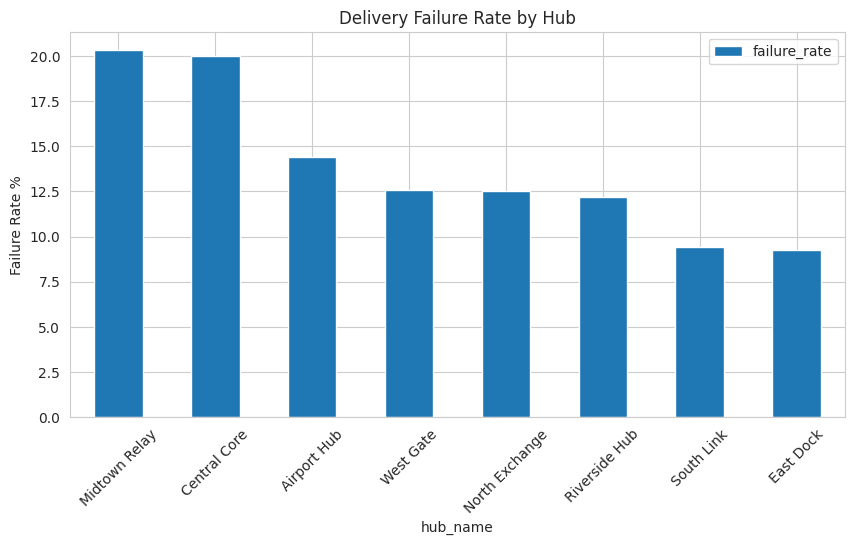

In [ ]:
#ANALYSIS 1 — HUB FAILURE RATE
hub_perf = deliveries.merge(hubs, on="hub_id")

hub_analysis = hub_perf.groupby("hub_name").agg(
    total_deliveries=("delivery_id", "count"),
    failed=("delivery_status", lambda x: (x=="Failed").sum())
)

hub_analysis["failure_rate"] = (hub_analysis["failed"] / hub_analysis["total_deliveries"]) * 100

hub_analysis = hub_analysis.sort_values("failure_rate", ascending=False)

hub_analysis[["failure_rate"]].plot(kind="bar", figsize=(10,5))
plt.title("Delivery Failure Rate by Hub")
plt.ylabel("Failure Rate %")
plt.xticks(rotation=45)
plt.show()

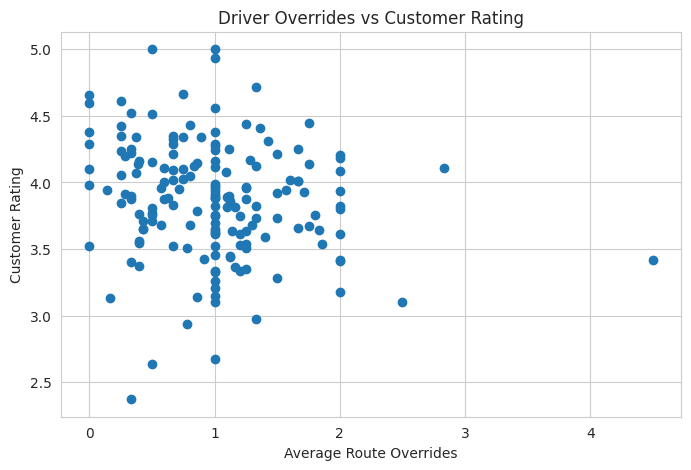

In [ ]:
#ANALYSIS 2 — DRIVER PERFORMANCE(Override VS Rating)
driver_perf = deliveries.merge(drivers, on="driver_id")

driver_summary = driver_perf.groupby("driver_id").agg(
    avg_overrides=("manual_route_override_count", "mean"),
    avg_rating=("customer_rating_post_delivery", "mean")
)

plt.figure(figsize=(8,5))
plt.scatter(driver_summary["avg_overrides"], driver_summary["avg_rating"])
plt.xlabel("Average Route Overrides")
plt.ylabel("Customer Rating")
plt.title("Driver Overrides vs Customer Rating")
plt.show()

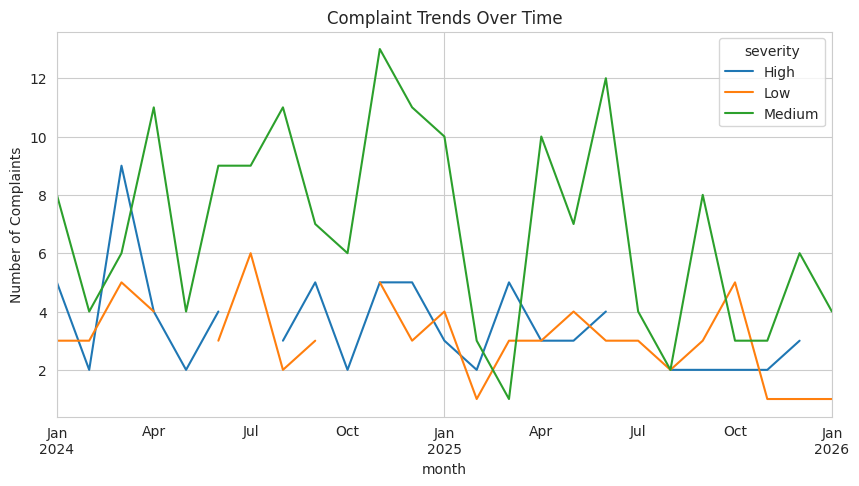

In [ ]:
#ANALYSIS 3 — COMPLAINT TRENDS
complaints["created_at"] = pd.to_datetime(complaints["created_at"])
complaints["month"] = complaints["created_at"].dt.to_period("M")

complaint_trend = complaints.groupby(["month", "severity"]).size().unstack()

complaint_trend.plot(kind="line", figsize=(10,5))
plt.title("Complaint Trends Over Time")
plt.ylabel("Number of Complaints")
plt.show()

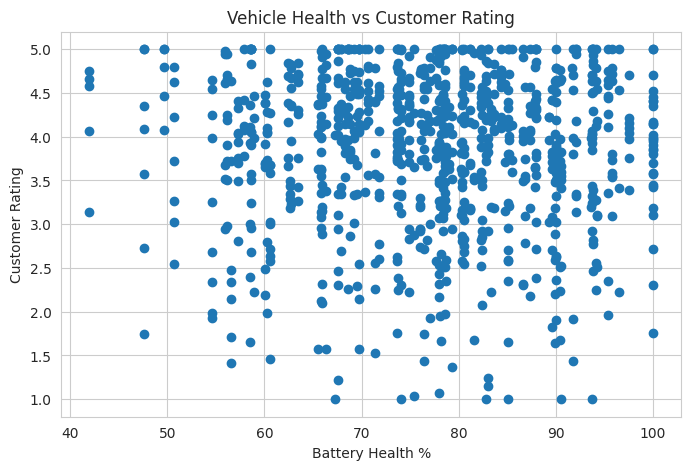

In [ ]:
#ANALYSIS 4 — VEHICLE HEALTH IMPACT
veh_data = deliveries.merge(vehicles, on="vehicle_id")

plt.figure(figsize=(8,5))
plt.scatter(veh_data["battery_health_pct"], veh_data["customer_rating_post_delivery"])
plt.xlabel("Battery Health %")
plt.ylabel("Customer Rating")
plt.title("Vehicle Health vs Customer Rating")
plt.show()

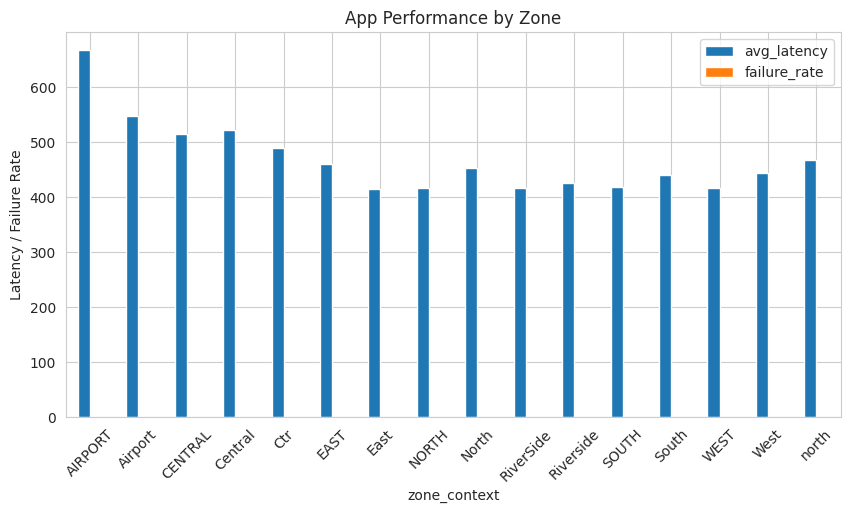

In [ ]:
#ANALYSIS 5 — APP PERFORMANCE
app_summary = app_events.groupby("zone_context").agg(
    avg_latency=("api_latency_ms", "mean"),
    failure_rate=("success_flag", lambda x: 1 - x.mean())
)

app_summary.plot(kind="bar", figsize=(10,5))
plt.title("App Performance by Zone")
plt.ylabel("Latency / Failure Rate")
plt.xticks(rotation=45)
plt.show()